# Advanced EDA 04 — Difference-in-Differences (DiD)
**Referencias:** Card & Krueger (1994) · Angrist & Pischke (2009) *Mostly Harmless Econometrics*, Cap. 5 · Callaway & Sant'Anna (2021) · Roth et al. (2023) *What's Trending in Difference-in-Differences?*

## Intuición
DiD compara el cambio en el resultado del **grupo tratado** antes y después del tratamiento, contra el cambio del **grupo control** en el mismo período:

$$\hat{\tau}^{DiD} = \underbrace{(\bar{Y}_{\text{treated, post}} - \bar{Y}_{\text{treated, pre}})}_{\text{cambio tratados}} - \underbrace{(\bar{Y}_{\text{control, post}} - \bar{Y}_{\text{control, pre}})}_{\text{cambio controles}}$$

## Estimador de regresión (Angrist & Pischke, Cap. 5)
$$Y_{it} = \alpha + \beta_1 \text{Treated}_i + \beta_2 \text{Post}_t + \delta (\text{Treated}_i \times \text{Post}_t) + \varepsilon_{it}$$
- $\beta_1$: diferencia pre-existente entre grupos
- $\beta_2$: tendencia temporal común
- $\delta$: **efecto causal del tratamiento** (el coeficiente de interés)

## Supuesto de Tendencias Paralelas (Parallel Trends)
> "In the absence of treatment, the average outcomes for the treated and control groups would have followed parallel paths over time." — Angrist & Pischke (2009, p. 228)

**No es testeable directamente** en el período post-tratamiento, pero se puede evaluar con evidencia pre-tratamiento.

In [10]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
    'font.family': 'Optima',
})
np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────────────
# Contexto: política de salario mínimo estatal (inspirado en Card & Krueger 1994)
# Estado A sube el salario mínimo en t=5. Estado B es el control.
# Outcome: employment rate en restaurantes de comida rápida
# ─────────────────────────────────────────────────────────────────────────────
N_units  = 200   # restaurantes por estado
T_pre    = 5     # períodos pre-tratamiento (t = 0..4)
T_post   = 5     # períodos post-tratamiento (t = 5..9)
T        = T_pre + T_post
TREAT_T  = T_pre  # período en que ocurre el tratamiento
TRUE_ATT = 2.5   # Average Treatment Effect on the Treated (verdadero)

# Heterogeneidad de unidades
unit_fe_treated = np.random.normal(30, 5, N_units)   # empleados promedio base (tratados)
unit_fe_control = np.random.normal(28, 5, N_units)   # empleados promedio base (controles)

rows = []
for t in range(T):
    is_post = int(t >= TREAT_T)
    # Tendencia común: +0.4 empleados por período
    common_trend = 0.4 * t
    # Estado tratado: efecto del tratamiento en post
    treat_effect = TRUE_ATT * is_post
    for i in range(N_units):
        # Tratados
        y_t = unit_fe_treated[i] + common_trend + treat_effect + np.random.normal(0, 2)
        rows.append({'unit': i, 'state': 'treated', 'period': t,
                     'post': is_post, 'treated': 1, 'employment': round(y_t, 2)})
        # Controles
        y_c = unit_fe_control[i] + common_trend + np.random.normal(0, 2)
        rows.append({'unit': N_units + i, 'state': 'control', 'period': t,
                     'post': is_post, 'treated': 0, 'employment': round(y_c, 2)})

df = pd.DataFrame(rows)
df['did'] = df['treated'] * df['post']

print(f'Panel: {df["unit"].nunique()} unidades × {T} períodos = {len(df):,} obs')
print(f'Tratados: {N_units} · Controles: {N_units} · Tratamiento en t={TREAT_T}')
print(f'ATT verdadero: {TRUE_ATT}')

Panel: 400 unidades × 10 períodos = 4,000 obs
Tratados: 200 · Controles: 200 · Tratamiento en t=5
ATT verdadero: 2.5


## 1 — Gráfica canónica de DiD: tendencias medias por grupo

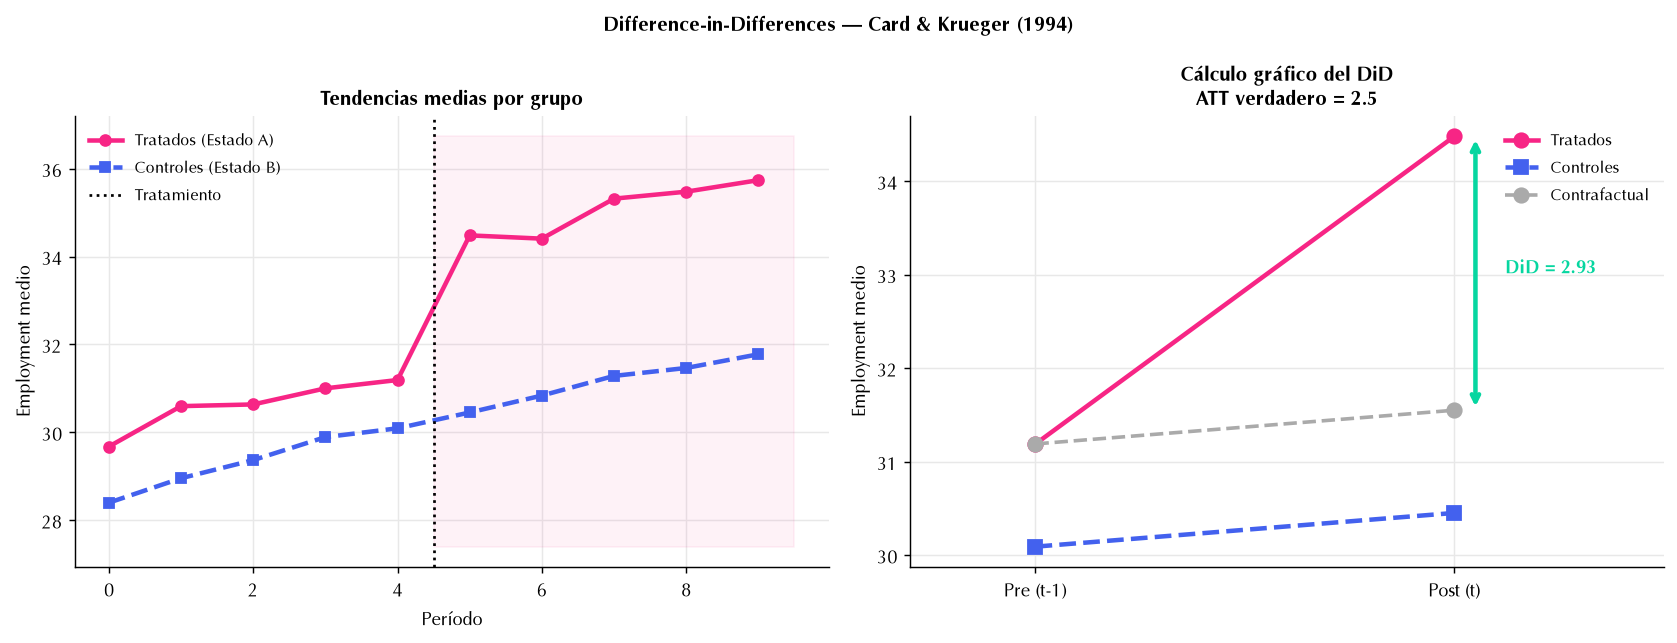

DiD estimado gráficamente: 2.9313  |  ATT verdadero: 2.5


In [11]:
means = df.groupby(['period', 'state'])['employment'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Panel A: tendencias medias ──────────────────────────────────────────────
ax = axes[0]
ax.plot(means.index, means['treated'], 'o-', color='#f72585', linewidth=2.5,
        markersize=6, label='Tratados (Estado A)')
ax.plot(means.index, means['control'], 's--', color='#4361ee', linewidth=2.5,
        markersize=6, label='Controles (Estado B)')
ax.axvline(TREAT_T - 0.5, color='black', linestyle=':', linewidth=1.5, label='Tratamiento')
ax.fill_betweenx([means.values.min()-1, means.values.max()+1],
                 TREAT_T - 0.5, T - 0.5, alpha=0.06, color='#f72585')
ax.set_xlabel('Período'); ax.set_ylabel('Employment medio')
ax.set_title('Tendencias medias por grupo')
ax.legend(fontsize=9)

# ── Panel B: cálculo gráfico del DiD ───────────────────────────────────────
ax2 = axes[1]
pre  = T_pre - 1          # último período pre
post = T_pre              # primer período post

# Contrafactual: qué hubieran hecho los tratados si no hubiera habido tratamiento
# = Nivel pre-tratado + cambio del control
delta_control = means.loc[post, 'control'] - means.loc[pre, 'control']
counterfactual_post = means.loc[pre, 'treated'] + delta_control

ax2.plot([pre, post], [means.loc[pre, 'treated'], means.loc[post, 'treated']],
         'o-', color='#f72585', linewidth=2.5, markersize=8, label='Tratados')
ax2.plot([pre, post], [means.loc[pre, 'control'], means.loc[post, 'control']],
         's--', color='#4361ee', linewidth=2.5, markersize=8, label='Controles')
ax2.plot([pre, post], [means.loc[pre, 'treated'], counterfactual_post],
         'o--', color='#aaa', linewidth=2, markersize=8, label='Contrafactual')

# Brecha DiD
did_estimate = means.loc[post, 'treated'] - counterfactual_post
ax2.annotate('', xy=(post + 0.05, means.loc[post, 'treated']),
             xytext=(post + 0.05, counterfactual_post),
             arrowprops=dict(arrowstyle='<->', color='#06d6a0', lw=2.5))
ax2.text(post + 0.12, (means.loc[post, 'treated'] + counterfactual_post)/2,
         f'DiD = {did_estimate:.2f}', fontsize=10, color='#06d6a0', fontweight='bold')

ax2.set_xlim(pre - 0.3, post + 0.5)
ax2.set_xticks([pre, post])
ax2.set_xticklabels(['Pre (t-1)', 'Post (t)'])
ax2.set_ylabel('Employment medio')
ax2.set_title(f'Cálculo gráfico del DiD\nATT verdadero = {TRUE_ATT}')
ax2.legend(fontsize=9)

plt.suptitle('Difference-in-Differences — Card & Krueger (1994)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'DiD estimado gráficamente: {did_estimate:.4f}  |  ATT verdadero: {TRUE_ATT}')

## 2 — Test de Tendencias Paralelas (Pre-Trends Test)

> "The most compelling evidence for parallel trends comes from showing that, in multiple pre-treatment periods, treated and control outcomes moved in parallel." — Roth et al. (2023, p. 2)

**Estrategia:** regresar el outcome sobre interacciones período × tratado para todos los períodos pre y post. Los coeficientes pre deben ser estadísticamente cero.

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_18246/3317117692.py:66: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Optima.
  plt.tight_layout()
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_18246/3317117692.py:66: UserWarning: Glyph 8342 (\N{LATIN SUBSCRIPT SMALL LETTER K}) missing from font(s) Optima.
  plt.tight_layout()
/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 948 (\N{GREEK SMALL LETTER DELTA}) missing from font(s) Optima.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8342 (\N{LATIN SUBSCRIPT SMALL LETTER K}) missing from font(s) Optima.
  fig.canvas.print_figure(bytes_io, **kw)


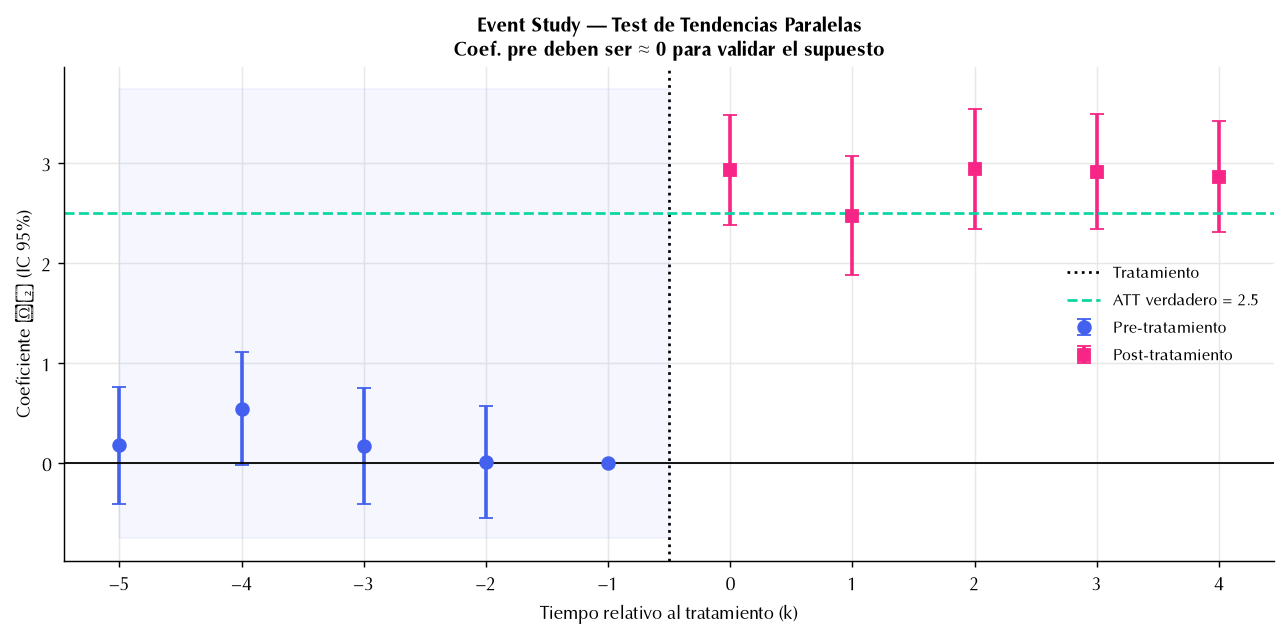

Test conjunto de pre-trends (H₀: δₖ = 0 para k < 0):
  F = 1.1355   p = 0.3393
  ✅ No se rechaza H₀ — tendencias paralelas plausibles


In [12]:
# Event study: Y_it = α_i + λ_t + Σ_k δ_k · (Treated_i × 1[t-T_treat = k]) + ε_it
# Período de referencia: t = T_pre - 1 (período justo antes del tratamiento)
REF_PERIOD = TREAT_T - 1
df['rel_time'] = df['period'] - TREAT_T   # tiempo relativo al tratamiento

# Crear dummies de interacción (excluir período de referencia)
rel_times = sorted(df['rel_time'].unique())
rel_times_no_ref = [r for r in rel_times if r != -1]  # omitir t-1 como referencia

for k in rel_times_no_ref:
    col = f'D_{k}' if k >= 0 else f'Dm{abs(k)}'
    df[col] = ((df['rel_time'] == k) & (df['treated'] == 1)).astype(int)

dummy_cols = [f'D_{k}' if k >= 0 else f'Dm{abs(k)}' for k in rel_times_no_ref]

# Incluir efectos fijos de unidad y período
X_es = pd.get_dummies(df[['unit', 'period']], columns=['unit', 'period'],
                      drop_first=True, dtype=float)
X_es = pd.concat([X_es, df[dummy_cols]], axis=1)

mod_es = sm.OLS(df['employment'], sm.add_constant(X_es)).fit(
    cov_type='cluster', cov_kwds={'groups': df['unit']})

# Extraer coeficientes e IC de los dummies de evento
event_coefs = pd.DataFrame({
    'rel_time': rel_times_no_ref,
    'coef':     [mod_es.params.get(c, np.nan) for c in dummy_cols],
    'se':       [mod_es.bse.get(c, np.nan)    for c in dummy_cols],
})
# Agregar el período de referencia (coef = 0 por construcción)
ref_row = pd.DataFrame({'rel_time': [-1], 'coef': [0.0], 'se': [0.0]})
event_coefs = pd.concat([event_coefs, ref_row]).sort_values('rel_time').reset_index(drop=True)
event_coefs['ci95'] = 1.96 * event_coefs['se']

# Gráfica de event study
fig, ax = plt.subplots(figsize=(10, 5))

pre_mask  = event_coefs['rel_time'] < 0
post_mask = event_coefs['rel_time'] >= 0

ax.errorbar(event_coefs.loc[pre_mask, 'rel_time'],
            event_coefs.loc[pre_mask, 'coef'],
            yerr=event_coefs.loc[pre_mask, 'ci95'],
            fmt='o', color='#4361ee', capsize=4, linewidth=2,
            markersize=7, label='Pre-tratamiento')

ax.errorbar(event_coefs.loc[post_mask, 'rel_time'],
            event_coefs.loc[post_mask, 'coef'],
            yerr=event_coefs.loc[post_mask, 'ci95'],
            fmt='s', color='#f72585', capsize=4, linewidth=2,
            markersize=7, label='Post-tratamiento')

ax.axhline(0, color='black', linewidth=1, linestyle='-')
ax.axvline(-0.5, color='black', linewidth=1.5, linestyle=':', label='Tratamiento')
ax.axhline(TRUE_ATT, color='#06d6a0', linewidth=1.5, linestyle='--',
           label=f'ATT verdadero = {TRUE_ATT}')
ax.fill_between([-5, -0.5], ax.get_ylim()[0], ax.get_ylim()[1],
                alpha=0.05, color='#4361ee')

ax.set_xlabel('Tiempo relativo al tratamiento (k)')
ax.set_ylabel('Coeficiente δₖ (IC 95%)')
ax.set_title('Event Study — Test de Tendencias Paralelas\nCoef. pre deben ser ≈ 0 para validar el supuesto')
ax.legend(fontsize=9)
ax.set_xticks(sorted(df['rel_time'].unique()))

plt.tight_layout()
plt.show()

# Test conjunto de pre-trends (H0: todos los coef. pre = 0)
pre_dummies = [f'Dm{abs(k)}' for k in rel_times_no_ref if k < 0]
R_matrix = np.zeros((len(pre_dummies), len(mod_es.params)))
for row, col_name in enumerate(pre_dummies):
    if col_name in mod_es.params.index:
        col_idx = list(mod_es.params.index).index(col_name)
        R_matrix[row, col_idx] = 1

f_test = mod_es.f_test(R_matrix)
print(f'Test conjunto de pre-trends (H₀: δₖ = 0 para k < 0):')
print(f'  F = {float(f_test.fvalue):.4f}   p = {float(f_test.pvalue):.4f}')
print(f'  {"✅ No se rechaza H₀ — tendencias paralelas plausibles" if float(f_test.pvalue) > 0.05 else "❌ Se rechaza H₀ — pre-trends significativos, supuesto cuestionable"}')

## 3 — Estimación por regresión OLS del DiD

La forma de regresión permite controlar covariables y calcular SE correctos (agrupados por unidad).

In [13]:
df_did = df.copy()

# Modelo 1: DiD simple (solo Treated × Post)
X1 = sm.add_constant(df_did[['treated', 'post', 'did']])
mod1 = sm.OLS(df_did['employment'], X1).fit(
    cov_type='cluster', cov_kwds={'groups': df_did['unit']})

# Modelo 2: DiD con efectos fijos de unidad y período (TWFE)
X2 = pd.get_dummies(df_did[['unit', 'period']], columns=['unit', 'period'],
                    drop_first=True, dtype=float)
X2['did'] = df_did['did'].values
X2 = sm.add_constant(X2)
mod2 = sm.OLS(df_did['employment'], X2).fit(
    cov_type='cluster', cov_kwds={'groups': df_did['unit']})

# Tabla comparativa
print('ESTIMACIÓN DiD')
print('═' * 60)
print(f'{"Modelo":<30} {"δ (DiD)":>10} {"SE":>8} {"p":>8} {"IC 95%":>18}')
print('─' * 60)
for label, mod in [('Simple (sin FE)', mod1), ('TWFE (unit + period FE)', mod2)]:
    coef = mod.params['did']
    se   = mod.bse['did']
    p    = mod.pvalues['did']
    lo   = mod.conf_int().loc['did', 0]
    hi   = mod.conf_int().loc['did', 1]
    print(f'{label:<30} {coef:>10.4f} {se:>8.4f} {p:>8.4f} [{lo:.3f}, {hi:.3f}]')

print('─' * 60)
print(f'ATT verdadero: {TRUE_ATT}')
print()
print('Interpretación del coeficiente DiD (δ):')
print('  La política de salario mínimo aumentó el empleo en')
print(f'  {mod2.params["did"]:.2f} empleados en promedio (p={mod2.pvalues["did"]:.4f})')
print('  → Consistente con Card & Krueger (1994): no se detecta reducción de empleo')

ESTIMACIÓN DiD
════════════════════════════════════════════════════════════
Modelo                            δ (DiD)       SE        p             IC 95%
────────────────────────────────────────────────────────────
Simple (sin FE)                    2.6433   0.1241   0.0000 [2.400, 2.886]
TWFE (unit + period FE)            2.6433   0.1309   0.0000 [2.387, 2.900]
────────────────────────────────────────────────────────────
ATT verdadero: 2.5

Interpretación del coeficiente DiD (δ):
  La política de salario mínimo aumentó el empleo en
  2.64 empleados en promedio (p=0.0000)
  → Consistente con Card & Krueger (1994): no se detecta reducción de empleo


## 4 — Distribución de grupos: balance pre-tratamiento

Antes de correr DiD hay que verificar que los grupos son comparables en el período pre-tratamiento (balance). Diferencias de nivel no invalidan DiD, pero sí ayudan a construir credibilidad.

Balance Pre-Tratamiento
───────────────────────────────────────────────────────
Tratados:  media=30.62  SD=5.11
Controles: media=29.34  SD=5.31
t-test:    t=5.484  p=0.0000
Cohen d:   0.245  (diferencia moderada/grande)

Nota: diferencia de nivel pre-tratamiento es aceptable en DiD.
Lo que importa es que las tendencias sean paralelas, no los niveles.


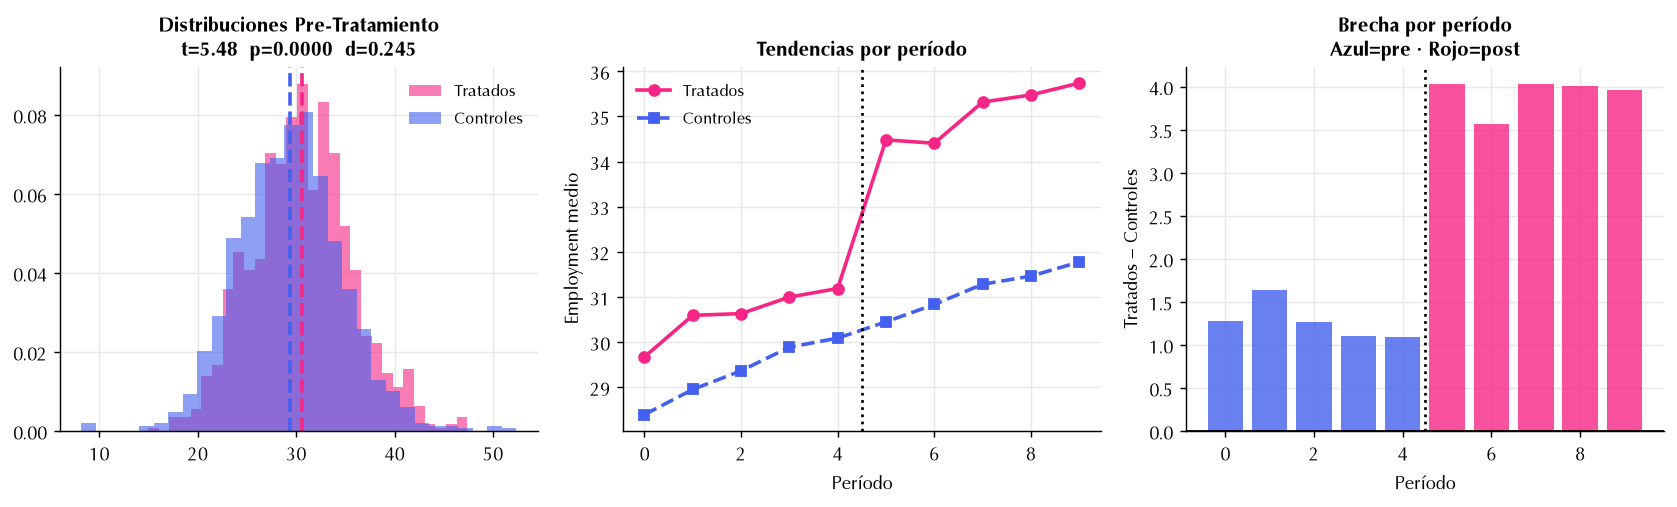

In [14]:
df_pre  = df[df['post'] == 0]
df_post = df[df['post'] == 1]

treated_pre = df_pre[df_pre['treated'] == 1]['employment']
control_pre = df_pre[df_pre['treated'] == 0]['employment']

# t-test de diferencia de medias pre-tratamiento
tstat, pval = stats.ttest_ind(treated_pre, control_pre)
cohen_d = (treated_pre.mean() - control_pre.mean()) / np.sqrt(
    (treated_pre.std()**2 + control_pre.std()**2) / 2)

print('Balance Pre-Tratamiento')
print('─' * 55)
print(f'Tratados:  media={treated_pre.mean():.2f}  SD={treated_pre.std():.2f}')
print(f'Controles: media={control_pre.mean():.2f}  SD={control_pre.std():.2f}')
print(f't-test:    t={tstat:.3f}  p={pval:.4f}')
print(f'Cohen d:   {cohen_d:.3f}  {"(diferencia pequeña)" if abs(cohen_d) < 0.2 else "(diferencia moderada/grande)"}')
print()
print('Nota: diferencia de nivel pre-tratamiento es aceptable en DiD.')
print('Lo que importa es que las tendencias sean paralelas, no los niveles.')

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Distribuciones pre-tratamiento
axes[0].hist(treated_pre, bins=30, alpha=0.6, color='#f72585', density=True, label='Tratados')
axes[0].hist(control_pre, bins=30, alpha=0.6, color='#4361ee', density=True, label='Controles')
axes[0].axvline(treated_pre.mean(), color='#f72585', linewidth=2, linestyle='--')
axes[0].axvline(control_pre.mean(), color='#4361ee', linewidth=2, linestyle='--')
axes[0].set_title(f'Distribuciones Pre-Tratamiento\nt={tstat:.2f}  p={pval:.4f}  d={cohen_d:.3f}')
axes[0].legend(fontsize=9)

# Evolución período a período
period_means = df.groupby(['period', 'treated'])['employment'].mean().unstack()
axes[1].plot(period_means.index, period_means[1], 'o-', color='#f72585', label='Tratados', linewidth=2)
axes[1].plot(period_means.index, period_means[0], 's--', color='#4361ee', label='Controles', linewidth=2)
axes[1].axvline(TREAT_T - 0.5, color='black', linestyle=':', linewidth=1.5)
axes[1].set_xlabel('Período'); axes[1].set_ylabel('Employment medio')
axes[1].set_title('Tendencias por período')
axes[1].legend(fontsize=9)

# Diferencia (Treated - Control) por período
diff_by_period = period_means[1] - period_means[0]
colors_bar = ['#4361ee' if t < TREAT_T else '#f72585' for t in diff_by_period.index]
axes[2].bar(diff_by_period.index, diff_by_period.values, color=colors_bar, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].axvline(TREAT_T - 0.5, color='black', linestyle=':', linewidth=1.5)
axes[2].set_xlabel('Período')
axes[2].set_ylabel('Tratados − Controles')
axes[2].set_title('Brecha por período\nAzul=pre · Rojo=post')

plt.tight_layout()
plt.show()

## 5 — Heterogeneidad del tratamiento (HTE)

El estimador DiD estándar (TWFE) recupera el ATT promedio. Con heterogeneidad, vale la pena explorar si el efecto varía entre subgrupos.

Heterogeneidad del Efecto de Tratamiento
  subgrupo  n_treat   coef     se   p  ci_lo  ci_hi
Size=small      100 2.7560 0.1773 0.0 2.4084 3.1035
Size=large      100 2.4945 0.1698 0.0 2.1617 2.8274


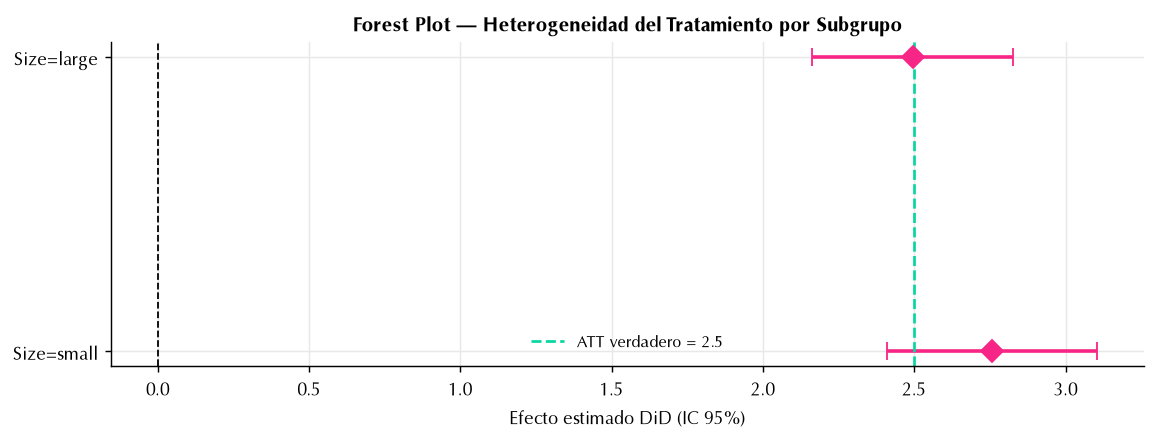

In [15]:
# Agregar covariable: tamaño del restaurante (pequeño/grande)
unit_sizes = pd.Series(
    np.random.choice(['small', 'large'], N_units * 2, p=[0.55, 0.45]),
    index=range(N_units * 2)
)
df['size'] = df['unit'].map(unit_sizes)

# DiD por subgrupo: solo en período pre y primer período post
df_treated_only = df[df['treated'] == 1].copy()

hte_results = []
for size in ['small', 'large']:
    subset = df_treated_only[df_treated_only['size'] == size]
    # Comparar contra todos los controles
    controls  = df[df['treated'] == 0].copy()
    controls['size'] = controls['unit'].map(unit_sizes)
    controls_size = controls[controls['size'] == size]

    d = pd.concat([subset, controls_size])
    X = sm.add_constant(d[['treated', 'post', 'did']])
    mod = sm.OLS(d['employment'], X).fit(
        cov_type='cluster', cov_kwds={'groups': d['unit']})

    hte_results.append({
        'subgrupo': f'Size={size}',
        'n_treat':  subset['unit'].nunique(),
        'coef':     mod.params['did'],
        'se':       mod.bse['did'],
        'p':        mod.pvalues['did'],
        'ci_lo':    mod.conf_int().loc['did', 0],
        'ci_hi':    mod.conf_int().loc['did', 1],
    })

hte_df = pd.DataFrame(hte_results)
print('Heterogeneidad del Efecto de Tratamiento')
print(hte_df.round(4).to_string(index=False))

# Forest plot
fig, ax = plt.subplots(figsize=(9, 3.5))
y_pos = range(len(hte_df))
ax.errorbar(hte_df['coef'], y_pos,
            xerr=1.96 * hte_df['se'],
            fmt='D', color='#f72585', capsize=5, linewidth=2, markersize=9)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.axvline(TRUE_ATT, color='#06d6a0', linewidth=1.5, linestyle='--',
           label=f'ATT verdadero = {TRUE_ATT}')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(hte_df['subgrupo'])
ax.set_xlabel('Efecto estimado DiD (IC 95%)')
ax.set_title('Forest Plot — Heterogeneidad del Tratamiento por Subgrupo')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6 — Problemas modernos de TWFE: Staggered DiD

> "When treatment timing varies, the TWFE coefficient is a weighted average of all 2×2 DiDs — and some weights can be negative." — Callaway & Sant'Anna (2021, p. 200)

Con adopción escalonada del tratamiento (staggered), el estimador TWFE puede ser sesgado e incluso cambiar de signo.

Staggered DiD — Problema del TWFE con efectos heterogéneos
───────────────────────────────────────────────────────
ATT por cohorte:  G4=3.0  G7=1.5  G10=0.5
ATT promedio verdadero: 1.67
TWFE estimado:          1.8831  ← puede estar sesgado



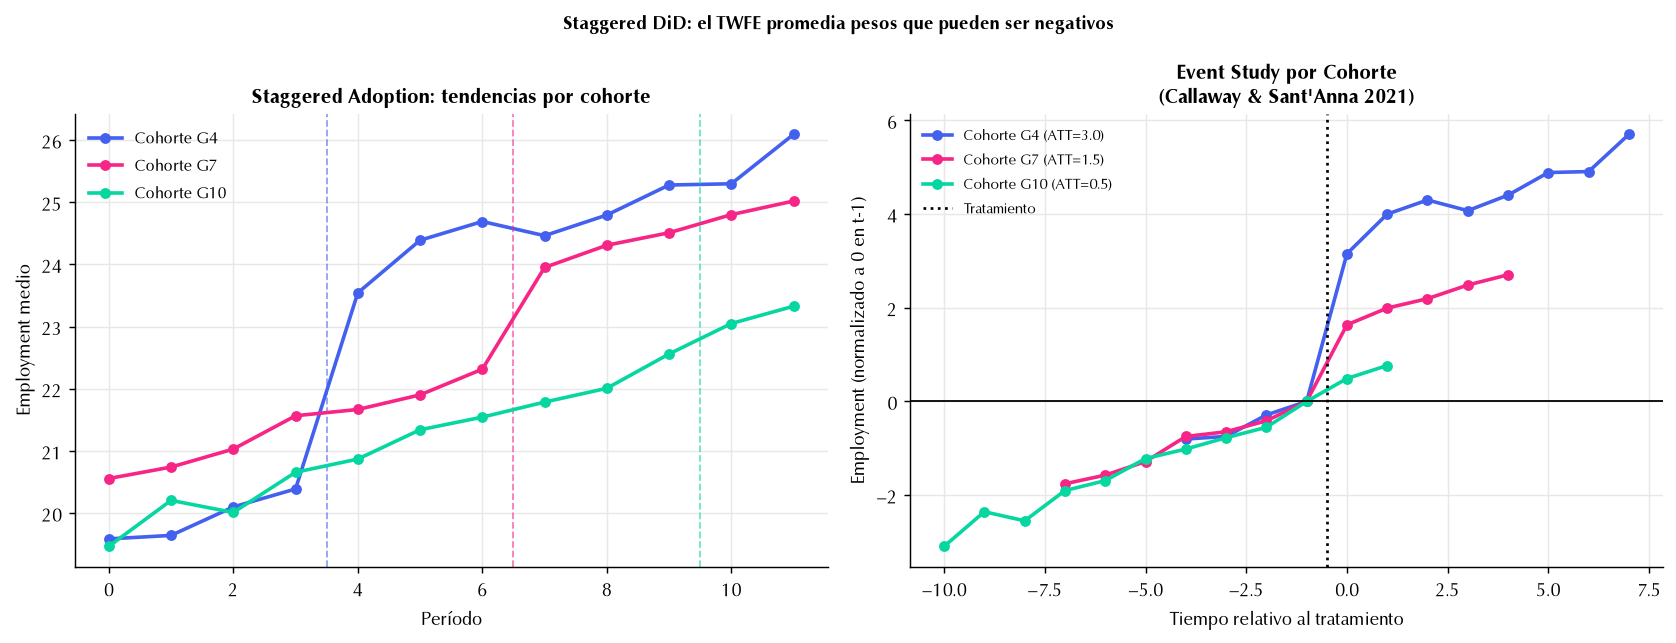

Solución: estimar ATT(g,t) por cohorte y agregar (Callaway & Sant'Anna 2021),
o usar el estimador de Borusyak, Jaravel & Spiess (2024) via absorción de FE.


In [16]:
# Staggered adoption: 3 cohortes de tratamiento
np.random.seed(42)
N_stag  = 60   # unidades por cohorte
T_stag  = 12

# Cohortes: tratamiento en t=4, t=7, t=10
cohorts = {4: 'Cohorte G4', 7: 'Cohorte G7', 10: 'Cohorte G10'}
ATT_by_cohort = {4: 3.0, 7: 1.5, 10: 0.5}  # efectos decrecientes — heterogéneos

rows_stag = []
unit_id = 0
for g, label in cohorts.items():
    afe = np.random.normal(20, 3, N_stag)
    for i in range(N_stag):
        for t in range(T_stag):
            treated_now = int(t >= g)
            y = afe[i] + 0.3*t + ATT_by_cohort[g] * treated_now + np.random.normal(0, 1.5)
            rows_stag.append({
                'unit': unit_id + i, 'cohort': g, 'cohort_label': label,
                'period': t, 'treated': treated_now, 'rel_time': t - g,
                'employment': round(y, 2),
            })
    unit_id += N_stag

df_stag = pd.DataFrame(rows_stag)
df_stag['post_any'] = df_stag['treated']   # ya es 1 si está tratado

# TWFE naïve en datos escalonados
X_twfe = pd.get_dummies(df_stag[['unit', 'period']], columns=['unit', 'period'],
                        drop_first=True, dtype=float)
X_twfe['treated'] = df_stag['treated'].values
mod_twfe = sm.OLS(df_stag['employment'], sm.add_constant(X_twfe)).fit(
    cov_type='cluster', cov_kwds={'groups': df_stag['unit']})

twfe_coef = mod_twfe.params['treated']
true_avg_att = np.mean(list(ATT_by_cohort.values()))

print('Staggered DiD — Problema del TWFE con efectos heterogéneos')
print('─' * 55)
print(f'ATT por cohorte:  G4={ATT_by_cohort[4]}  G7={ATT_by_cohort[7]}  G10={ATT_by_cohort[10]}')
print(f'ATT promedio verdadero: {true_avg_att:.2f}')
print(f'TWFE estimado:          {twfe_coef:.4f}  ← puede estar sesgado')
print()

# Event study por cohorte (enfoque Callaway & Sant'Anna)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tendencias medias por cohorte
ax = axes[0]
colors_cohort = ['#4361ee', '#f72585', '#06d6a0']
for (g, label), color in zip(cohorts.items(), colors_cohort):
    d = df_stag[df_stag['cohort'] == g].groupby('period')['employment'].mean()
    ax.plot(d.index, d.values, 'o-', color=color, linewidth=2, markersize=5, label=label)
    ax.axvline(g - 0.5, color=color, linewidth=1, linestyle='--', alpha=0.6)

ax.set_xlabel('Período'); ax.set_ylabel('Employment medio')
ax.set_title('Staggered Adoption: tendencias por cohorte')
ax.legend(fontsize=9)

# Event study por cohorte (tiempo relativo)
ax2 = axes[1]
for (g, label), color in zip(cohorts.items(), colors_cohort):
    d = df_stag[df_stag['cohort'] == g].groupby('rel_time')['employment'].mean()
    # Normalizar por el nivel en rel_time = -1
    base = d.get(-1, d.iloc[0])
    ax2.plot(d.index, d.values - base, 'o-', color=color, linewidth=2,
             markersize=5, label=f'{label} (ATT={ATT_by_cohort[g]})')

ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(-0.5, color='black', linewidth=1.5, linestyle=':', label='Tratamiento')
ax2.set_xlabel('Tiempo relativo al tratamiento')
ax2.set_ylabel('Employment (normalizado a 0 en t-1)')
ax2.set_title('Event Study por Cohorte\n(Callaway & Sant\'Anna 2021)')
ax2.legend(fontsize=8)

plt.suptitle('Staggered DiD: el TWFE promedia pesos que pueden ser negativos', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()
print('Solución: estimar ATT(g,t) por cohorte y agregar (Callaway & Sant\'Anna 2021),')
print('o usar el estimador de Borusyak, Jaravel & Spiess (2024) via absorción de FE.')

## 7 — Checklist de validación DiD

```
Antes de interpretar el estimador DiD:

✅ 1. Tendencias paralelas en pre-tratamiento
        → Event study: coeficientes pre-tratamiento ≈ 0
        → Test conjunto F no significativo (p > 0.05)

✅ 2. Balance pre-tratamiento en covariables
        → Distribuciones similares entre grupos en t < T_treat
        → Diferencias de nivel son aceptables

✅ 3. No hay anticipación del tratamiento
        → Agentes no cambian comportamiento antes del tratamiento
        → Coeficientes en t-1 deben ser ≈ 0

✅ 4. SUTVA (Stable Unit Treatment Value Assumption)
        → El tratamiento de unidad i no afecta el outcome de unidad j
        → No hay spillovers entre grupos

✅ 5. Si hay staggered adoption:
        → Verificar heterogeneidad de efectos entre cohortes
        → Usar estimadores robustos (Callaway & Sant'Anna 2021)

✅ 6. Errores estándar:
        → Clusterizar por unidad de tratamiento
        → Con pocos clusters → bootstrap o permutation test
```

## Resumen

| Elemento | Qué verificar | Herramienta |
|---|---|---|
| Tendencias paralelas | Coef. pre ≈ 0 | Event study + F-test conjunto |
| Balance pre | Distribuciones similares | t-test, Cohen d, histogramas |
| Estimación | ATT | TWFE con cluster SE |
| HTE | Variación del efecto | DiD por subgrupo, forest plot |
| Staggered | Pesos negativos | Event study por cohorte |

**Referencias:**
- Card, D. & Krueger, A.B. (1994). Minimum wages and employment. *American Economic Review*, 84(4).
- Angrist, J.D. & Pischke, J.S. (2009). *Mostly Harmless Econometrics*. Princeton University Press.
- Callaway, B. & Sant'Anna, P.H.C. (2021). Difference-in-differences with multiple time periods. *Journal of Econometrics*, 225(2).
- Roth, J., Sant'Anna, P.H.C., Bilinski, A. & Poe, J. (2023). What's trending in difference-in-differences? *Journal of Econometrics*, 235(2).
- Borusyak, K., Jaravel, X. & Spiess, J. (2024). Revisiting event study designs. *Review of Economic Studies*, 91(6).
- Goodman-Bacon, A. (2021). Difference-in-differences with variation in treatment timing. *Journal of Econometrics*, 225(2).